## Data Preprocessing

<br>

<hr>



In [ ]:
# %pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File handling
import zipfile

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### Reading directly from the ZIP file, as the datasets go over the github file size limit (25mb)

In [4]:
import pandas as pd
import zipfile

zip_path = "../00_Data/original_kaggle_data_download_archive.zip"

with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())  # See what files are inside

    # df1 = pd.read_csv(z.open("1429_1.csv"))
    df = pd.read_csv(z.open("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
    # df3 = pd.read_csv(z.open("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))

['1429_1.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv']


## Dataset Overview

In [6]:

print("\nShape:")
print(df.shape)

print("\nFirst rows:")
display(df.head())

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nStatistics:")
display(df.describe(include="all"))


Shape:
(5000, 24)

First rows:


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,manufacturer,manufacturerNumber,reviews.date,reviews.dateAdded,reviews.dateSeen,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,Amazon,B00ZV9PXP2,2017-09-03T00:00:00.000Z,NaN,"2018-05-27T00:00:00Z,2017-09-18T00:00:00Z,2017...",False,NaN,0,3,http://reviews.bestbuy.com/3545/5442403/review...,I thought it would be as big as small paper bu...,Too small,llyyue,https://www.newegg.com/Product/Product.aspx%25...
1,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,Amazon,B00ZV9PXP2,2017-06-06T00:00:00.000Z,NaN,"2018-05-27T00:00:00Z,2017-07-07T00:00:00Z,2017...",True,NaN,0,5,http://reviews.bestbuy.com/3545/5442403/review...,This kindle is light and easy to use especiall...,Great light reader. Easy to use at the beach,Charmi,https://www.newegg.com/Product/Product.aspx%25...
2,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,Amazon,B00ZV9PXP2,2018-04-20T00:00:00.000Z,NaN,2018-05-27T00:00:00Z,True,NaN,0,4,https://reviews.bestbuy.com/3545/5442403/revie...,Didnt know how much i'd use a kindle so went f...,Great for the price,johnnyjojojo,https://www.newegg.com/Product/Product.aspx%25...
3,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,Amazon,B00ZV9PXP2,2017-11-02T17:33:31.000Z,NaN,2018-10-09T00:00:00Z,True,177283626.0,3,5,https://redsky.target.com/groot-domain-api/v1/...,I am 100 happy with my purchase. I caught it o...,A Great Buy,Kdperry,https://www.newegg.com/Product/Product.aspx%25...
4,AVqVGZNvQMlgsOJE6eUY,2017-03-03T16:56:05Z,2018-10-25T16:36:31Z,"Amazon Kindle E-Reader 6"" Wifi (8th Generation...",B00ZV9PXP2,Amazon,"Computers,Electronics Features,Tablets,Electro...",Electronics,https://pisces.bbystatic.com/image2/BestBuy_US...,allnewkindleereaderblack6glarefreetouchscreend...,Amazon,B00ZV9PXP2,2018-04-24T00:00:00.000Z,NaN,2018-05-27T00:00:00Z,True,NaN,0,5,https://reviews.bestbuy.com/3545/5442403/revie...,Solid entry level Kindle. Great for kids. Gift...,Solid entry-level Kindle. Great for kids,Johnnyblack,https://www.newegg.com/Product/Product.aspx%25...



Info:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   5000 non-null   str    
 1   dateAdded            5000 non-null   str    
 2   dateUpdated          5000 non-null   str    
 3   name                 5000 non-null   str    
 4   asins                5000 non-null   str    
 5   brand                5000 non-null   str    
 6   categories           5000 non-null   str    
 7   primaryCategories    5000 non-null   str    
 8   imageURLs            5000 non-null   str    
 9   keys                 5000 non-null   str    
 10  manufacturer         5000 non-null   str    
 11  manufacturerNumber   5000 non-null   str    
 12  reviews.date         5000 non-null   str    
 13  reviews.dateAdded    1052 non-null   str    
 14  reviews.dateSeen     5000 non-null   str    
 15  reviews.doRecommend  5000 non-null   bool 

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,manufacturer,manufacturerNumber,reviews.date,reviews.dateAdded,reviews.dateSeen,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,1052,5000,5000,2.900000e+01,5000.000000,5000.000000,5000,5000,4987,4999,5000
unique,24,20,17,23,24,1,23,4,24,24,1,24,679,381,417,2,NaN,NaN,NaN,2827,4385,3124,3814,24
top,AVqkIhwDv8e3D1O-lebb,2017-03-06T14:59:43Z,2018-09-21T18:45:21Z,Amazon Echo Show Alexa-enabled Bluetooth Speak...,B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Electronics,https://i5.walmartimages.com/asr/c494506a-b347...,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,53-004484,2017-01-23T00:00:00.000Z,2017-09-01T09:52:19Z,2018-04-26T00:00:00Z,True,NaN,NaN,NaN,https://redsky.target.com/groot-domain-api/v1/...,Bought this mostly as a backup.and to read a f...,Great tablet,Mike,http://www.walmart.com/ip/All-New-Fire-HD-8-Ta...
freq,797,797,1429,845,797,5000,797,3276,797,797,5000,797,125,31,1217,4765,NaN,NaN,NaN,24,4,122,26,797
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.858740e+08,0.312400,4.596800,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.084040e+07,3.111582,0.731804,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.082112e+08,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.851185e+08,0.000000,4.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.880757e+08,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.981949e+08,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN


## Visualize Missing Values

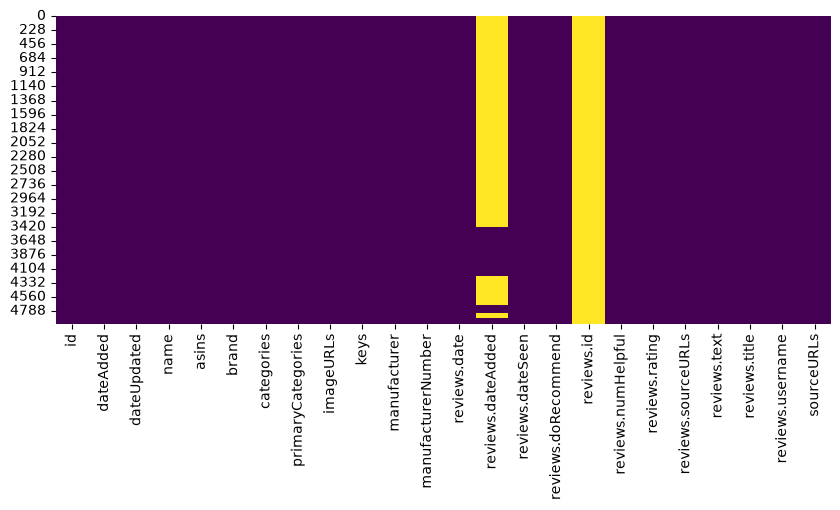

In [7]:


plt.figure(figsize=(10,4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

#plt.title(name)
plt.show()

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())


Missing Values:
id                        0
dateAdded                 0
dateUpdated               0
name                      0
asins                     0
brand                     0
categories                0
primaryCategories         0
imageURLs                 0
keys                      0
manufacturer              0
manufacturerNumber        0
reviews.date              0
reviews.dateAdded      3948
reviews.dateSeen          0
reviews.doRecommend       0
reviews.id             4971
reviews.numHelpful        0
reviews.rating            0
reviews.sourceURLs        0
reviews.text              0
reviews.title            13
reviews.username          1
sourceURLs                0
dtype: int64

Duplicates: 95


### Clean Data

In [9]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

    # Remove completely empty rows
df.dropna(how="all", inplace=True)

In [10]:
print("\nShape:")
print(df.shape)


Shape:
(4905, 24)


### Inspect Column Names

In [11]:


print(df.columns.tolist())
print()

['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand', 'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer', 'manufacturerNumber', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs']



### Correlation

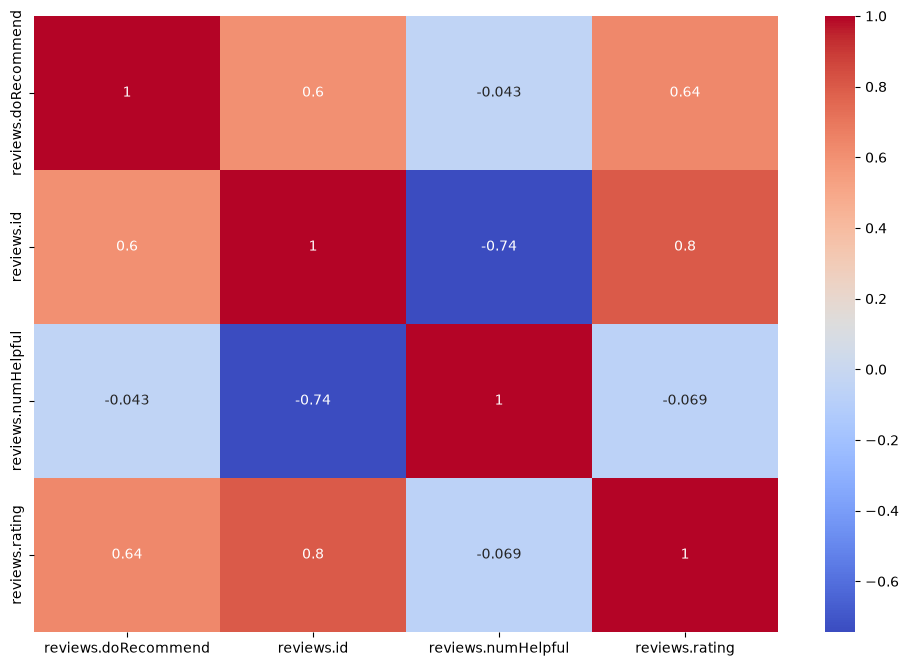

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()